In [30]:
#importing  the libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random


In [31]:
torchvision.__version__

'0.25.0+cu128'

In [32]:
torch.cuda.is_available()

True

In [33]:
#set device adgnistic code

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

In [34]:
print(f"using device: {device}")

using device: cuda


In [35]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

In [36]:
#setting the hyper parametrs
BATCH_SIZE = 128
EPOCHS=10
LEARNING_RATE =3e-4
PATCH_SIZE=4
NUM_CLASSES =10
IMAGE_SIZE = 32
CHANNELS =3
EMBED_DIM = 256
NUM_HEAD =8
DEPTH = 6
MLP_DIM = 512
DROP_RATE =0.1



In [37]:
#define image transformation operation

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))# helps to convert faster/Make numerical computations stable


])

In [38]:
#getting the data set

train_data = datasets.CIFAR10(root="data",
                              train=True,
                              download= True,
                              transform= transform
                              )

In [39]:
test_data = datasets.CIFAR10(root="data",
                            train=False,
                            download = True,
                            transform=transform)

In [40]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [41]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )

In [42]:
len(train_data)

50000

In [43]:
len(test_data)

10000

converting these data sets into dataloaders
why
right now our data into pytorch datasets
dataloaders turn data into batches(mini batches)
Why?

1. it is more computationaly efficient  to 128 images at a time
2. It gives our NN more chanse to update its gradiests per epochs


In [44]:
train_loader = DataLoader(dataset =train_data,
                          batch_size = BATCH_SIZE,
                          shuffle = True)
test_loader = DataLoader(dataset =test_data,
                          batch_size = BATCH_SIZE,
                          shuffle = False)

In [45]:
#chacking what we created
print(f"total train batches: {len(train_loader)}")
print(f"total test batches: {len(test_loader)}")

total train batches: 391
total test batches: 79


In [46]:
#building out ViT components from scratch


In [61]:
class PatchEmbedding(nn.Module):
  def __init__(self,
               patch_size,
               in_channels,
               embed_dim
               ):
    super().__init__()
    self.patch_size = patch_size
    self.proj = nn.Conv2d(in_channels=in_channels,
                          out_channels=embed_dim,
                          kernel_size =patch_size,
                          stride=patch_size)
    num_patches = (IMAGE_SIZE//patch_size)**2
    self.cls_token = nn.Parameter(torch.randn(1,1,embed_dim))
    self.pos_embed = nn.Parameter(torch.randn(1,1+num_patches,embed_dim))

  def forward(self,x:torch.Tensor):
    B = x.size(0)
    x = self.proj(x) #B,E,H/P,W/B
    x = x.flatten(2).transpose(1,2) #B,P,E
    cls_token = self.cls_token.expand(B,-1,-1)
    x = torch.cat((cls_token,x),dim=1)
    x=x+self.pos_embed
    return x


In [66]:
#define multilayer perceptron class

class MLP(nn.Module):
  def __init__(self,
               in_features,
               hidden_features,
               drop_rate):
    super().__init__()
    self.fc1 = nn.Linear(in_features=in_features,
                         out_features=hidden_features)
    #self.drop = nn.Dropout(p=drop_rate)
    self.fc2 = nn.Linear(in_features=hidden_features,
                         out_features=in_features)
    self.dropout = nn.Dropout(p=drop_rate)

  def forward(self,x):
    x= self.dropout(F.gelu(self.fc1(x)))
    x=self.dropout(self.fc2(x))
    return x





In [67]:
class TransformerEncoderlayer(nn.Module):
  def __init__(self, embed_dim,num_heads,mlp_dim,drop_rate):
    super().__init__()
    self.norm1 = nn.LayerNorm(embed_dim)
    self.attn = nn.MultiheadAttention(embed_dim=embed_dim,
                                       num_heads=num_heads,
                                       dropout=drop_rate,
                                      batch_first = True)
    self.norm2 = nn.LayerNorm(embed_dim)
    self.mlp = MLP(in_features=embed_dim,
                   hidden_features=mlp_dim,
                   drop_rate=drop_rate)
  def forward(self,x):
    x = x + self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
    x = x + self.mlp(self.norm2(x))
    return x

In [70]:
class VisionTransformer(nn.Module):
  def __init__(self, img_size,patch_size, in_channels,num_classes,embed_dim,depth,num_heads,mlp_dim,drop_rate):
    super().__init__()
    self.patch_embed = PatchEmbedding(patch_size=patch_size,
                                      in_channels=in_channels,
                                      embed_dim=embed_dim)
    self.encoder = nn.Sequential(*[TransformerEncoderlayer(embed_dim=embed_dim,
                                                            num_heads=num_heads,
                                                            mlp_dim=mlp_dim,
                                                            drop_rate=drop_rate)
    for _ in range (depth)])
    self.norm =nn.LayerNorm(embed_dim)
    self.head = nn.Linear(embed_dim,num_classes)

  def forward(self,x):
    x = self.patch_embed(x)
    x = self.encoder(x)
    x = self.norm(x)
    cls_token =x[:,0]
    return self.head(cls_token)

In [73]:
#Intansiater the model

model = VisionTransformer(
    IMAGE_SIZE,
    PATCH_SIZE,
    CHANNELS,
    NUM_CLASSES,
    EMBED_DIM,
    DEPTH,
    NUM_HEAD,
    MLP_DIM,
    DROP_RATE
).to(device)

In [74]:
model

VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoderlayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoderlayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP

In [77]:
from torch.optim.optimizer import ParamsT
#defining a loss function and a optimizer

criterion  = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = model.parameters(),
                          lr = LEARNING_RATE)

In [78]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)

In [79]:
#defining a traning loop function

def train(model,loader,optimizer,criterion):
  #set tmode of the model
  model.train()

  total_loss, correct  =0,0

  for x,y in loader:
    #sending the data into the target device
    x,y = x.to(device),y.to(device)
    optimizer.zero_grad()

    #forward pass
    out = model(x)

    # claulate the loss per batch
    loss = criterion(out,y)
    #perform back prom
    loss.backward()

    # perform the gradient decent
    optimizer.step()

    total_loss +=loss.item()* x.size(0 )

    correct +=(out.argmax(1)==y).sum().item()
  # nomalize the loss to generalize it across the batches
  return total_loss/len(loader.dataset),correct/len(loader.dataset)

In [80]:
def evaluate(model,loader):
  model.eval() #set the mode of the model evaluation

  correct =0

  with torch.inference_mode():
    for x, y in loader:
      x,y = x.to(device),y.to(device)

      out = model(x)

      correct += (out.argmax(dim=1)==y).sum().item()
  return correct / len(loader.dataset)

In [81]:
from tqdm.auto import tqdm

In [83]:
#training

train_accuracies = []
test_accuracies =[]

for epochs in tqdm(range (EPOCHS)):
  train_loss, train_acc = train(model,train_loader,optimizer,criterion)
  test_acc = evaluate(model,test_loader)

  train_accuracies.append(train_acc)
  test_accuracies.append(test_acc)

  print(f"Epoch:{epochs+1}/{EPOCHS},Train Loss : {train_loss:.4f},train_acc: {train_acc:.4f}, Test+acc: {test_acc:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch:1/10,Train Loss : 1.3976,train_acc: 0.4977, Test+acc: 0.5222
Epoch:2/10,Train Loss : 1.2375,train_acc: 0.5556, Test+acc: 0.5658
Epoch:3/10,Train Loss : 1.1293,train_acc: 0.5988, Test+acc: 0.5968
Epoch:4/10,Train Loss : 1.0351,train_acc: 0.6297, Test+acc: 0.6012
Epoch:5/10,Train Loss : 0.9545,train_acc: 0.6609, Test+acc: 0.6215
Epoch:6/10,Train Loss : 0.8796,train_acc: 0.6855, Test+acc: 0.6212
Epoch:7/10,Train Loss : 0.8094,train_acc: 0.7123, Test+acc: 0.6294
Epoch:8/10,Train Loss : 0.7296,train_acc: 0.7385, Test+acc: 0.6228
Epoch:9/10,Train Loss : 0.6657,train_acc: 0.7610, Test+acc: 0.6351
Epoch:10/10,Train Loss : 0.5918,train_acc: 0.7902, Test+acc: 0.6410


In [84]:
train_accuracies

[0.4977,
 0.55564,
 0.59882,
 0.62972,
 0.66092,
 0.68548,
 0.71228,
 0.73848,
 0.76102,
 0.7902]

In [85]:
test_accuracies

[0.5222, 0.5658, 0.5968, 0.6012, 0.6215, 0.6212, 0.6294, 0.6228, 0.6351, 0.641]

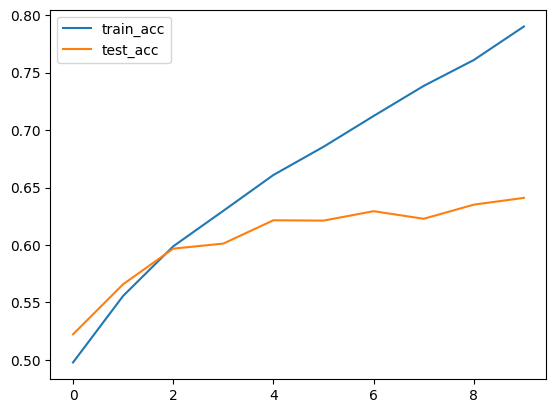

In [86]:
plt.plot(train_accuracies,label="train_acc")
plt.plot(test_accuracies,label="test_acc")
plt.legend()
plt.show()

In [93]:
def predict_and_plot_grid(model,
                          dataset,
                          classes,
                          grid_state=3):
  model.eval()
  fig,axes = plt.subplots(grid_state,grid_state,figsize=(9,9))
  for i in range(grid_state):
    for j in range(grid_state):
      idx = random.randint(0,len(dataset)-1)
      img,true_label = dataset[idx]
      input_tensor = img.unsqueeze(dim=0).to(device)
      with torch.inference_mode():
        output = model(input_tensor)
        _, predicted = torch.max(output.data, 1)
        img = img / 2 + 0.5  # unormalizing the images to be able to plot them with matplot lib
        npimg =img.cpu().numpy()
        axes[i,j].imshow(np.transpose(npimg,(1,2,0)))
        truth = classes[true_label]== classes[predicted.item()]
        if truth:
          color ="g"
        else:
          color ="r"


        axes[i,j].set_title(f"truth : {classes[true_label]}\n, predicted : {classes[predicted.item()]}", fontsize =10 ,c= color)
        axes[i,j].axis("off")
  plt.tight_layout()
  plt.show()






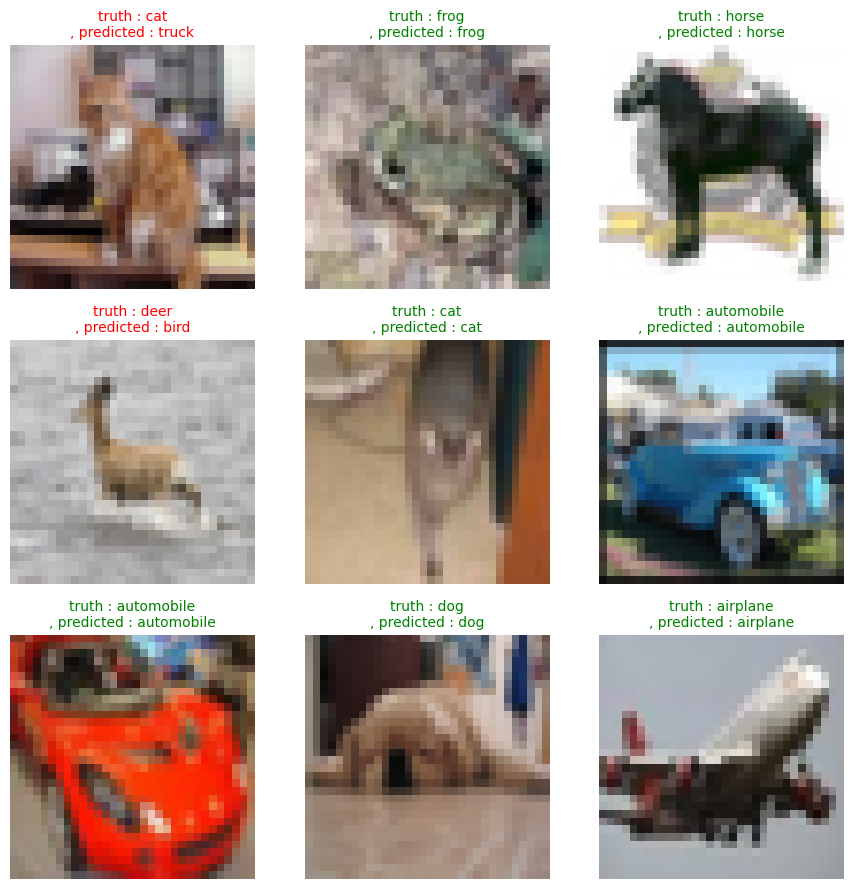

In [94]:
predict_and_plot_grid(model,test_data,classes=train_data.classes,grid_state=3)